# PHY 5103 — Homework 1 computational checks

Problems: CH1 : **1, 2, 7, 11, 18, 20, 22**

Handwritten derivations are the submission. this is symbolic computational (residuals/independent checks, limiting case etgc)


In [1]:
#setup
import os
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from scipy.integrate import solve_ivp
from IPython.display import display, Image

sp.init_printing()
plt.style.use('dark_background')

os.makedirs('graphs', exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'graphs/{name}', dpi=300, bbox_inches='tight')


# Problem 1

In [3]:
#symbolic check of both identities from the hand derivation
t = sp.symbols('t', real=True)
m0 = sp.symbols('m0', positive=True)

vx = sp.Function('v_x')(t)
vy = sp.Function('v_y')(t)
vz = sp.Function('v_z')(t)

v = sp.Matrix([vx, vy, vz])
a = sp.diff(v, t)

#constant mass: dT/dt = F dot v
T_const = sp.Rational(1, 2) * m0 * v.dot(v)
F_const = m0 * a

res_const = sp.simplify(sp.diff(T_const, t) - F_const.dot(v))

#variable mass: d(mT)/dt = F dot p, with F = dp/dt
m_t = sp.Function('m')(t)
p = m_t * v
F_var = sp.diff(p, t)
T_var = sp.Rational(1, 2) * m_t * v.dot(v)

res_var = sp.simplify(sp.diff(m_t * T_var, t) - F_var.dot(p))

print('constant-mass residual:')
display(res_const)

print('variable-mass residual:')
display(res_var)


constant-mass residual:


variable-mass residual:


# Problem 2

In [4]:
#exact n-body check of the COM identity
#using integers so this is exact will skip floating point

masses = [sp.Integer(2), sp.Integer(5), sp.Integer(3), sp.Integer(7), sp.Integer(4)]
r = [
    sp.Matrix([ 1,  2, -1]),
    sp.Matrix([-3,  0,  4]),
    sp.Matrix([ 2, -2,  1]),
    sp.Matrix([ 0,  5, -3]),
    sp.Matrix([ 4,  1,  2]),
]

def com_identity_residual(masses, positions):
    M = sum(masses)
    Rvec = sum((mi * ri for mi, ri in zip(masses, positions)), sp.zeros(3, 1)) / M

    lhs = sp.expand(M**2 * Rvec.dot(Rvec))
    first = M * sum(mi * ri.dot(ri) for mi, ri in zip(masses, positions))

    pair_sum = 0
    for i in range(len(masses)):
        for j in range(len(masses)):
            rij = positions[i] - positions[j]
            pair_sum += masses[i] * masses[j] * rij.dot(rij)

    rhs = sp.expand(first - sp.Rational(1, 2) * pair_sum)
    return sp.simplify(lhs - rhs)

res_origin = com_identity_residual(masses, r)

#same system after changing origin
shift = sp.Matrix([3, -2, 5])
r_shifted = [ri + shift for ri in r]
res_shifted = com_identity_residual(masses, r_shifted)

#and after a rigid 90 degree rotation about z
Rz = sp.Matrix([[0, -1, 0],
                [1,  0, 0],
                [0,  0, 1]])
r_rotated = [Rz * ri for ri in r]
res_rotated = com_identity_residual(masses, r_rotated)

print('identity residual at original origin:')
display(res_origin)

print('after translating the origin:')
display(res_shifted)

print('after rigid rotation:')
display(res_rotated)


identity residual at original origin:


after translating the origin:


after rigid rotation:


# Problem 7

In [6]:
#Nielsen form IS --> a chain rule identity
#can use a deliberately nontrivial T(q, qdot, t) --> check both sides independently
q1 = sp.Function('q_1')(t)
q2 = sp.Function('q_2')(t)
q1d = sp.diff(q1, t)
q2d = sp.diff(q2, t)

T7 = (
    sp.Rational(1, 2) * (1 + q2**2) * q1d**2
    + q1 * q2 * q1d * q2d
    + sp.Rational(1, 2) * (2 + q1**2) * q2d**2
    + sp.sin(t) * q1d * q2d
)

T7dot = sp.diff(T7, t)

for label, q, qd in [('q1', q1, q1d), ('q2', q2, q2d)]:
    lagrange_form = sp.diff(sp.diff(T7, qd), t) - sp.diff(T7, q)
    nielsen_form = sp.diff(T7dot, qd) - 2 * sp.diff(T7, q)

    residual = sp.simplify(sp.expand(nielsen_form - lagrange_form))
    print(f'{label} Nielsen - Lagrange residual:')
    display(residual)


q1 Nielsen - Lagrange residual:


q2 Nielsen - Lagrange residual:


# Problem 11

general rolling-disk acceleration:


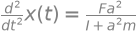

uniform thin disk:


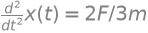

newton cross-check:


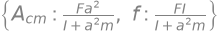

thin-disk newton result:


In [8]:
#symbolic lagrange result + independent newton check

m, I, a, F = sp.symbols('m I a F', positive=True)
x = sp.Function('x')(t)
xd = sp.diff(x, t)
xdd = sp.diff(x, t, 2)

#rolling constraint phi = x/a has already been used
L11 = sp.Rational(1, 2) * (m + I/a**2) * xd**2

EL11 = sp.simplify(sp.diff(sp.diff(L11, xd), t) - sp.diff(L11, x) - F)
xdd_lagrange = sp.solve(sp.Eq(EL11, 0), xdd)[0]

print('general rolling-disk acceleration:')
display(sp.Eq(xdd, xdd_lagrange))

#thin disk I = 1/2 m a^2
xdd_thin = sp.simplify(xdd_lagrange.subs(I, sp.Rational(1, 2) * m * a**2))
print('uniform thin disk:')
display(sp.Eq(xdd, xdd_thin))

#same answer from translation + torque
#f is the backward static friction mag
Acm, f = sp.symbols('A_cm f', real=True)
newton = [
    sp.Eq(F - f, m * Acm),
    sp.Eq(f * a, I * (Acm / a)),
]
newton_sol = sp.solve(newton, (Acm, f), simplify=True)

print('newton cross-check:')
display(newton_sol)

print('thin-disk newton result:')
display({
    Acm: sp.simplify(newton_sol[Acm].subs(I, sp.Rational(1, 2) * m * a**2)),
    f: sp.simplify(newton_sol[f].subs(I, sp.Rational(1, 2) * m * a**2)),
})


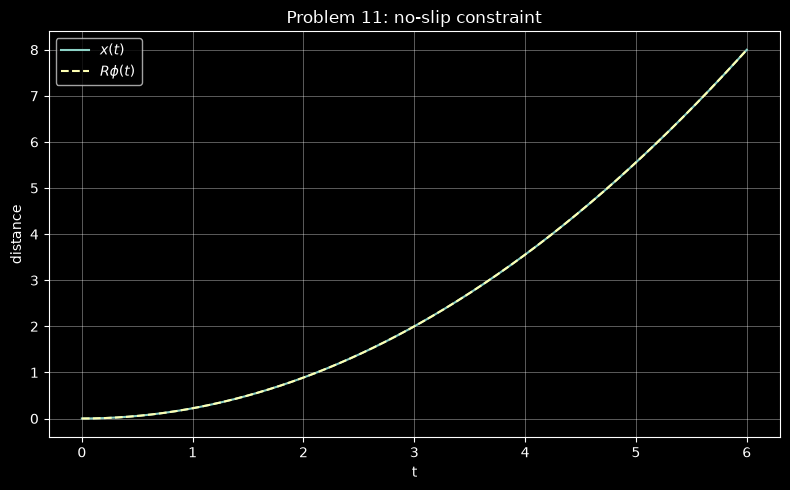

max |x - R phi| = 0.0


In [11]:
#lets visualize no-slip condition; arbitrary units, only checkin kinematics

m_val = 12.0
R_val = 4.0
F_val = 8.0
I_val = 0.5 * m_val * R_val**2

acc = F_val / (m_val + I_val / R_val**2)

t_vals = np.linspace(0, 6, 400)
x_vals = 0.5 * acc * t_vals**2
phi_vals = x_vals / R_val

plt.figure(figsize=(8, 5))
plt.plot(t_vals, x_vals, label=r'$x(t)$')
plt.plot(t_vals, R_val * phi_vals, '--', label=r'$R\phi(t)$')
plt.xlabel('t')
plt.ylabel('distance')
plt.title('Problem 11: no-slip constraint')
plt.grid(True)
plt.legend()
savefig('p11_no_slip_check.png')
plt.show()

print('max |x - R phi| =', np.max(np.abs(x_vals - R_val * phi_vals)))


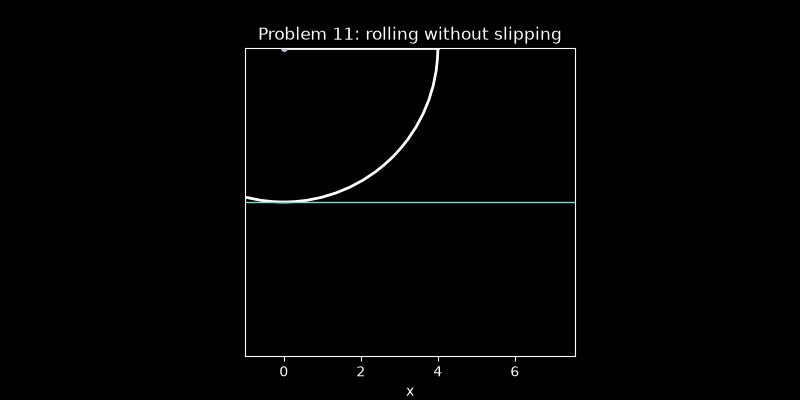

In [17]:
#make a gif of the rolling disk
frames = 150
tt = np.linspace(0, 5, frames)
xx = 0.5 * acc * tt**2
ph = xx / R_val

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1, xx[-1] + 2)
ax.set_ylim(-4, 4)
ax.set_xlabel('x')
ax.set_yticks([])
ax.set_title('Problem 11: rolling without slipping')

ax.plot([-1, xx[-1] + 2], [0, 0], lw=1)

disk = plt.Circle((0, R_val), R_val, fill=False, lw=2)
ax.add_patch(disk)
spoke, = ax.plot([], [], lw=2)
center, = ax.plot([], [], 'o', ms=4)

def update_disk(i):
    xc = xx[i]
    angle = -ph[i]  #clockwise for motion to the right

    disk.center = (xc, R_val)
    center.set_data([xc], [R_val])

    xs = xc + R_val * np.cos(angle)
    ys = R_val + R_val * np.sin(angle)
    spoke.set_data([xc, xs], [R_val, ys])

    return disk, spoke, center

ani11 = animation.FuncAnimation(fig, update_disk, frames=frames, interval=35, blit=False)
ani11.save('graphs/p11_rolling_disk.gif', writer='pillow', fps=28)
plt.close(fig)

display(Image(filename='graphs/p11_rolling_disk.gif'))


# Problem 18

In [18]:
#symbolic check of the E-L equations in matrix form

m, K, a, b, c = sp.symbols('m K a b c', nonzero=True)
x = sp.Function('x')(t)
y = sp.Function('y')(t)
xd = sp.diff(x, t)
yd = sp.diff(y, t)

L18 = (
    m / 2 * (a * xd**2 + 2 * b * xd * yd + c * yd**2)
    - K / 2 * (a * x**2 + 2 * b * x * y + c * y**2)
)

EL18 = sp.Matrix([
    sp.diff(sp.diff(L18, xd), t) - sp.diff(L18, x),
    sp.diff(sp.diff(L18, yd), t) - sp.diff(L18, y),
])

A18 = sp.Matrix([[a, b], [b, c]])
q18 = sp.Matrix([x, y])
q18dd = sp.diff(q18, t, 2)

matrix_target = A18 * (m * q18dd + K * q18)

print('E-L minus A(m qdd + K q):')
display(sp.simplify(EL18 - matrix_target))

print('det(A):')
display(sp.factor(A18.det()))

print('velocity Hessian det:')
H18 = sp.hessian(L18, (xd, yd))
display(sp.factor(H18.det()))

#the two special cases in the problem are invertible but indefinite
A_case1 = A18.subs({a: 0, c: 0})
A_case2 = A18.subs({b: 0, c: -a})

print('a = c = 0 eigenvalues:')
display(A_case1.eigenvals())

print('b = 0, c = -a eigenvalues:')
display(A_case2.eigenvals())


E-L minus A(m qdd + K q):


⎡0⎤
⎢ ⎥
⎣0⎦

det(A):


velocity Hessian det:


a = c = 0 eigenvalues:


b = 0, c = -a eigenvalues:


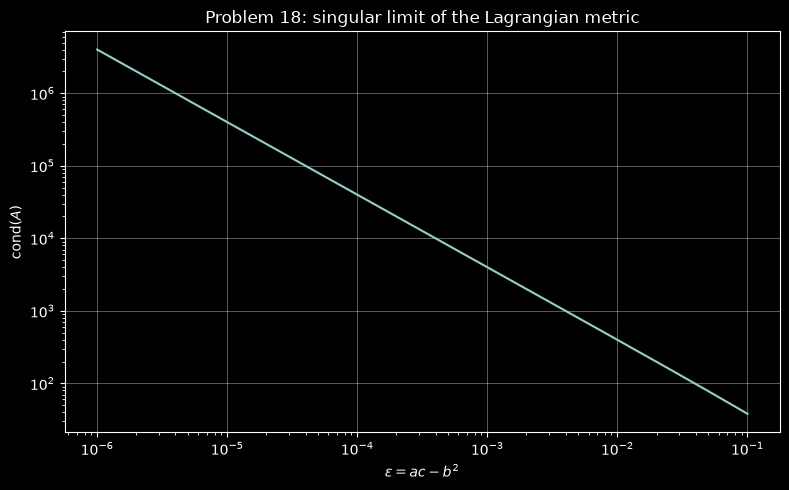

condition number at smallest epsilon: 3999998.001123488


In [19]:
#what b^2-ac != 0 is buying us numerically
#if approach det(A)=0 from the PD side --> watch inversion explode

eps_vals = np.logspace(-6, -1, 250)
cond_vals = []

for eps in eps_vals:
    #a=c=1 and choose b so det(A)=eps
    b_val = np.sqrt(1.0 - eps)
    A_num = np.array([[1.0, b_val],
                      [b_val, 1.0]])
    cond_vals.append(np.linalg.cond(A_num))

cond_vals = np.asarray(cond_vals)

plt.figure(figsize=(8, 5))
plt.loglog(eps_vals, cond_vals)
plt.xlabel(r'$\epsilon = ac-b^2$')
plt.ylabel(r'cond$(A)$')
plt.title('Problem 18: singular limit of the Lagrangian metric')
plt.grid(True)
savefig('p18_condition_number.png')
plt.show()

print('condition number at smallest epsilon:', cond_vals[0])


# Problem 20

factorized E-L equation:


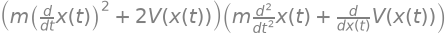

check against (m v^2 + 2V)(m xdd + Vprime):


Lagrangian energy:


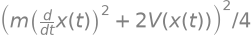

E_L - E_Newton^2:


velocity Hessian:


Hessian - 2m E_Newton:


In [21]:
#factor the E-L equation (energy, veloy hessian indepdenently)

m = sp.symbols('m', positive=True)
x = sp.Function('x')(t)
v = sp.diff(x, t)
V = sp.Function('V')

L20 = m**2 * v**4 / 12 + m * v**2 * V(x) - V(x)**2

EL20 = sp.factor(sp.diff(sp.diff(L20, v), t) - sp.diff(L20, x))
E20 = sp.factor(v * sp.diff(L20, v) - L20)
H20 = sp.factor(sp.diff(L20, v, 2))

E_newton = m * v**2 / 2 + V(x)

print('factorized E-L equation:')
display(EL20)

print('check against (m v^2 + 2V)(m xdd + Vprime):')
target20 = (m * v**2 + 2 * V(x)) * (m * sp.diff(x, t, 2) + sp.diff(V(x), x))
display(sp.simplify(EL20 - target20))

print('Lagrangian energy:')
display(E20)

print('E_L - E_Newton^2:')
display(sp.simplify(E20 - E_newton**2))

print('velocity Hessian:')
display(H20)

print('Hessian - 2m E_Newton:')
display(sp.simplify(H20 - 2 * m * E_newton))


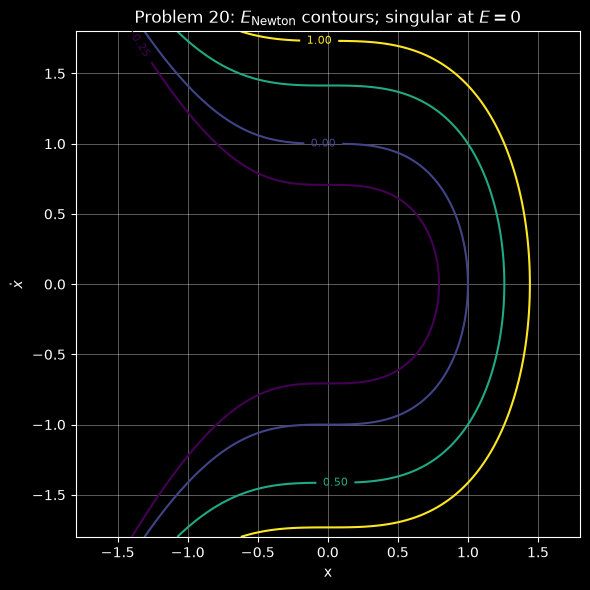

for x=1, v=0: 2mE_Newton = 0.0


In [25]:
#show singluar set for one *simple potential, for simplicity

x_grid = np.linspace(-1.8, 1.8, 500)
v_grid = np.linspace(-1.8, 1.8, 500)
X, VV = np.meshgrid(x_grid, v_grid)

Estd = 0.5 * VV**2 + 0.5 * X**(3) - 0.5

plt.figure(figsize=(6, 6))
cs = plt.contour(X, VV, Estd, levels=[-0.25, 0.0, 0.5, 1.0])
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel('x')
plt.ylabel(r'$\dot{x}$')
plt.title(r'Problem 20: $E_{\rm Newton}$ contours; singular at $E=0$')
plt.grid(True)
savefig('p20_singular_energy_surface.png')
plt.show()

#at a point on E=0 the coefficient multiplying xdd vanishes
#example x=1, v=0
print('for x=1, v=0: 2mE_Newton =', 2 * (0.5 * 0**2 + 0.5 * 1**2 - 0.5))


# Problem 22

In [26]:
#derive T, V, E-L equations from cartesian geometry
#this checks the hand derivation before doing any numerical dynamics

m1, m2, l1, l2, g = sp.symbols('m1 m2 l1 l2 g', positive=True)

theta1 = sp.Function('theta_1')(t)
theta2 = sp.Function('theta_2')(t)
w1 = sp.diff(theta1, t)
w2 = sp.diff(theta2, t)
alpha1 = sp.diff(theta1, t, 2)
alpha2 = sp.diff(theta2, t, 2)
Delta = theta1 - theta2

x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)
x2 = x1 + l2 * sp.sin(theta2)
y2 = y1 - l2 * sp.cos(theta2)

T22 = (
    sp.Rational(1, 2) * m1 * (sp.diff(x1, t)**2 + sp.diff(y1, t)**2)
    + sp.Rational(1, 2) * m2 * (sp.diff(x2, t)**2 + sp.diff(y2, t)**2)
)
V22 = m1 * g * y1 + m2 * g * y2
L22 = sp.simplify(T22 - V22)

T22_target = (
    sp.Rational(1, 2) * (m1 + m2) * l1**2 * w1**2
    + sp.Rational(1, 2) * m2 * l2**2 * w2**2
    + m2 * l1 * l2 * w1 * w2 * sp.cos(Delta)
)

EL22_1 = sp.expand_trig(sp.diff(sp.diff(L22, w1), t) - sp.diff(L22, theta1))
EL22_2 = sp.expand_trig(sp.diff(sp.diff(L22, w2), t) - sp.diff(L22, theta2))

target22_1 = (
    (m1 + m2) * l1**2 * alpha1
    + m2 * l1 * l2 * sp.cos(Delta) * alpha2
    + m2 * l1 * l2 * sp.sin(Delta) * w2**2
    + (m1 + m2) * g * l1 * sp.sin(theta1)
)

target22_2 = (
    m2 * l2**2 * alpha2
    + m2 * l1 * l2 * sp.cos(Delta) * alpha1
    - m2 * l1 * l2 * sp.sin(Delta) * w1**2
    + m2 * g * l2 * sp.sin(theta2)
)

def trig_zero(expr):
    return sp.trigsimp(sp.expand_trig(expr))

print('T residual:')
display(trig_zero(T22 - T22_target))

print('theta1 E-L residual:')
display(trig_zero(EL22_1 - target22_1))

print('theta2 E-L residual:')
display(trig_zero(EL22_2 - target22_2))

#same Hessian as the coupled mass matrix
H22 = sp.hessian(L22, (w1, w2))
det_target = m2 * l1**2 * l2**2 * (m1 + m2 * sp.sin(Delta)**2)

print('mass-matrix determinant residual:')
display(trig_zero(H22.det() - det_target))


T residual:


theta1 E-L residual:


theta2 E-L residual:


mass-matrix determinant residual:


eigenvalues = omega^2:


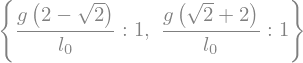

frequencies:


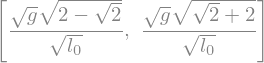

In [13]:
#small-angle normal-mode check for equal masses and lengths
#M0 qdd + K0 q = 0

m0, l0 = sp.symbols('m0 l0', positive=True)

M0 = m0 * l0**2 * sp.Matrix([[2, 1],
                              [1, 1]])
K0 = m0 * g * l0 * sp.Matrix([[2, 0],
                               [0, 1]])

omega_sq = sp.simplify(M0.inv() * K0)

print('eigenvalues = omega^2:')
display(omega_sq.eigenvals())

print('frequencies:')
display([
    sp.sqrt((g/l0) * (2 - sp.sqrt(2))),
    sp.sqrt((g/l0) * (2 + sp.sqrt(2))),
])


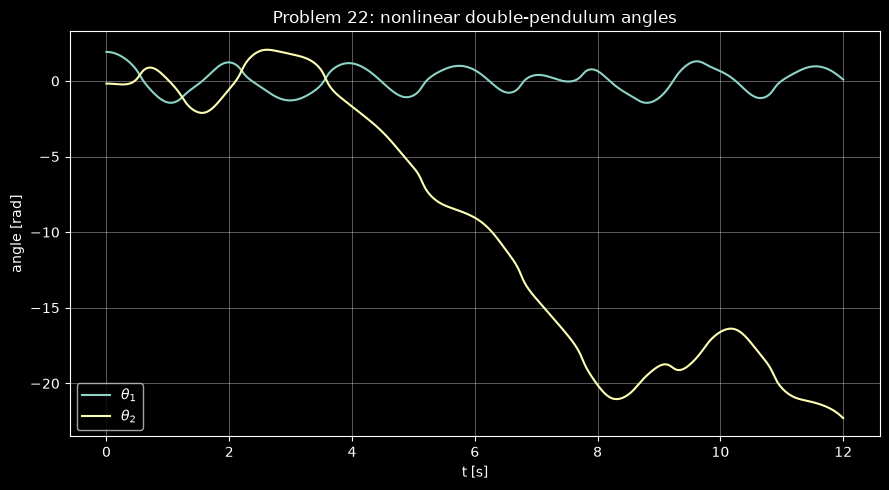

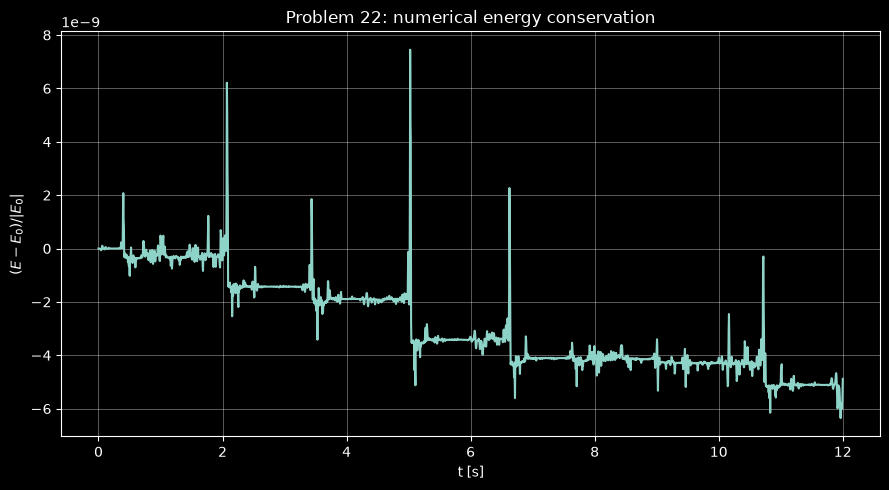

max relative energy drift = 7.4477997802540455e-09


In [27]:
#nonlinear numerical solve
#arbitrary physical values; point is energy conservation + qualitative motion

pars = {
    'm1': 1.0,
    'm2': 1.0,
    'l1': 1.0,
    'l2': 1.0,
    'g': 9.81,
}

def double_pendulum_rhs(t, z, p=pars):
    th1, om1, th2, om2 = z
    m1v, m2v = p['m1'], p['m2']
    l1v, l2v, gv = p['l1'], p['l2'], p['g']

    D = th1 - th2
    cD = np.cos(D)
    sD = np.sin(D)

    M = np.array([
        [(m1v + m2v) * l1v**2, m2v * l1v * l2v * cD],
        [m2v * l1v * l2v * cD, m2v * l2v**2],
    ])

    rhs = np.array([
        -m2v * l1v * l2v * sD * om2**2
        - (m1v + m2v) * gv * l1v * np.sin(th1),

        +m2v * l1v * l2v * sD * om1**2
        - m2v * gv * l2v * np.sin(th2),
    ])

    al1, al2 = np.linalg.solve(M, rhs)
    return [om1, al1, om2, al2]

def total_energy(z, p=pars):
    th1, om1, th2, om2 = z
    m1v, m2v = p['m1'], p['m2']
    l1v, l2v, gv = p['l1'], p['l2'], p['g']

    D = th1 - th2

    T = (
        0.5 * (m1v + m2v) * l1v**2 * om1**2
        + 0.5 * m2v * l2v**2 * om2**2
        + m2v * l1v * l2v * om1 * om2 * np.cos(D)
    )

    V = (
        -(m1v + m2v) * gv * l1v * np.cos(th1)
        - m2v * gv * l2v * np.cos(th2)
    )
    return T + V

z0 = np.radians([110.0, 0.0, -10.0, 0.0])
t_eval = np.linspace(0, 12, 2401)

sol22 = solve_ivp(
    double_pendulum_rhs,
    (t_eval[0], t_eval[-1]),
    z0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12,
    method='DOP853',
)

th1_num = sol22.y[0]
th2_num = sol22.y[2]

plt.figure(figsize=(9, 5))
plt.plot(sol22.t, th1_num, label=r'$\theta_1$')
plt.plot(sol22.t, th2_num, label=r'$\theta_2$')
plt.xlabel('t [s]')
plt.ylabel('angle [rad]')
plt.title('Problem 22: nonlinear double-pendulum angles')
plt.grid(True)
plt.legend()
savefig('p22_angles.png')
plt.show()

E = np.array([total_energy(sol22.y[:, i]) for i in range(sol22.y.shape[1])])
rel_drift = (E - E[0]) / max(abs(E[0]), 1.0)

plt.figure(figsize=(9, 5))
plt.plot(sol22.t, rel_drift)
plt.xlabel('t [s]')
plt.ylabel(r'$(E-E_0)/|E_0|$')
plt.title('Problem 22: numerical energy conservation')
plt.grid(True)
savefig('p22_energy_drift.png')
plt.show()

print('max relative energy drift =', np.max(np.abs(rel_drift)))


In [28]:
#convergence sanity check
#same initial condition, only tighten solver tolerances

for rtol in [1e-6, 1e-8, 1e-10]:
    sol_test = solve_ivp(
        double_pendulum_rhs,
        (0, 12),
        z0,
        t_eval=np.linspace(0, 12, 1201),
        rtol=rtol,
        atol=rtol * 1e-2,
        method='DOP853',
    )

    E_test = np.array([
        total_energy(sol_test.y[:, i])
        for i in range(sol_test.y.shape[1])
    ])

    drift = np.max(np.abs((E_test - E_test[0]) / max(abs(E_test[0]), 1.0)))
    print(f'rtol={rtol:1.0e}  max relative energy drift={drift:.3e}')


rtol=1e-06  max relative energy drift=1.123e-04
rtol=1e-08  max relative energy drift=1.274e-06
rtol=1e-10  max relative energy drift=6.239e-09


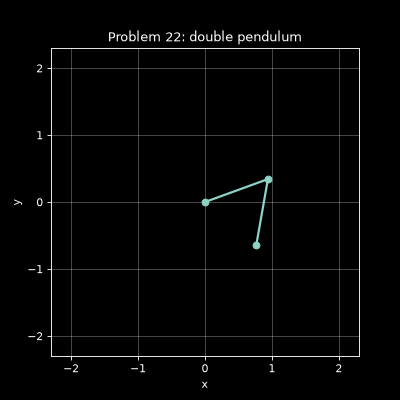

In [31]:
#double pendulum gif
#ill subsample the accurate solution so the file stays reasonable

idx = np.linspace(0, len(sol22.t) - 1, 480, dtype=int) #480 frames
th1_gif = th1_num[idx]
th2_gif = th2_num[idx]

l1v, l2v = pars['l1'], pars['l2']

x1_gif = l1v * np.sin(th1_gif)
y1_gif = -l1v * np.cos(th1_gif)
x2_gif = x1_gif + l2v * np.sin(th2_gif)
y2_gif = y1_gif - l2v * np.cos(th2_gif)

fig, ax = plt.subplots(figsize=(5, 5))
lim = 1.15 * (l1v + l2v)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_title('Problem 22: double pendulum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True)

line, = ax.plot([], [], 'o-', lw=2)
trail, = ax.plot([], [], lw=1, alpha=0.5)

trail_n = 40

def update_pendulum(i):
    line.set_data(
        [0, x1_gif[i], x2_gif[i]],
        [0, y1_gif[i], y2_gif[i]],
    )

    j0 = max(0, i - trail_n)
    trail.set_data(x2_gif[j0:i+1], y2_gif[j0:i+1])
    return line, trail

ani22 = animation.FuncAnimation(
    fig,
    update_pendulum,
    frames=len(idx),
    interval=35,
    blit=False,
)

ani22.save('graphs/p22_double_pendulum.gif', writer='pillow', fps=48, dpi=80)
plt.close(fig)

display(Image(filename='graphs/p22_double_pendulum.gif'))


## outputs

All static figures and GIFs are written to `graphs/` when the notebook is run
- will sync to my git
